# Shakespeare Language Model — From-Scratch Mamba

Train a language model on Shakespeare's complete works using our from-scratch
`ResidualBlock` (MambaBlock + RMSNorm + residual).

Supports **character-level**, **BPE**, and **GPT-2** tokenization strategies.

| Section | Contents |
|---------|----------|
| 1. Setup & Data | Download corpus, choose tokenizer, inspect dataset |
| 2. Model | Stack multiple ResidualBlocks into a language model |
| 3. Data Pipeline & Profiling | Dataset/DataLoader, torch.profiler analysis |
| 4. Training | Epoch-based training with AdamW + cosine LR |
| 5. Evaluation | Loss curves, perplexity, per-position analysis |
| 6. Generation | Sample text from the trained model |


In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────
%pip install tqdm ninja einops tokenizers transformers wandb -q

# Download mamba_block.py and fused_scan.py
# Need to edit mamba_block.py fused_scan import
# ".fused_scan" -> "fused_scan"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 4.8 MB/s eta 0:00:00


In [2]:
import os, sys, math, time, random
from dataclasses import dataclass, field

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
import wandb

# ── Path setup ────────────────────────────────────────────────────────────
sys.path.insert(0, os.path.join(os.getcwd(), "mamba"))
from mamba_block import MambaBlock, ResidualBlock, RMSNorm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type != "cuda":
    print("WARNING: GPU strongly recommended. Go to Runtime -> Change runtime type -> T4 GPU")


Device: cuda


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: doryvf (doryvf-rochester-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Dataset & Tokenizer

We use the **Tiny Shakespeare** corpus (~1.1 MB, ~1.1M characters).

Three tokenizer options:
- **char** — character-level, vocab ~65, 1 token per character (baseline)
- **bpe** — BPE trained on Shakespeare, configurable vocab (256–4096), ~3–5x compression
- **gpt2** — pre-trained GPT-2 BPE, vocab 50257, ~5–7x compression


In [4]:
# ── Download corpus ───────────────────────────────────────────────────────
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "shakespeare.txt"

if not os.path.exists(DATA_PATH):
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, "r") as f:
    text = f.read()

print(f"Corpus size:  {len(text):,} characters")
print(f"Sample:\n{'─' * 60}")
print(text[:500])


Corpus size:  1,115,394 characters
Sample:
────────────────────────────────────────────────────────────
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [5]:
# ── Tokenizer selection ───────────────────────────────────────────────────
# Change TOKENIZER_MODE to switch strategy. Everything downstream adapts.

TOKENIZER_MODE = "bpe"    # "char", "bpe", or "gpt2"
BPE_VOCAB_SIZE = 512      # only used when mode = "bpe"

# ── Option A: Character-level ─────────────────────────────────────────────
class CharTokenizer:
    def __init__(self, text):
        chars = sorted(set(text))
        self.vocab_size = len(chars)
        self._stoi = {ch: i for i, ch in enumerate(chars)}
        self._itos = {i: ch for ch, i in self._stoi.items()}
    def encode(self, s):
        return [self._stoi[c] for c in s]
    def decode(self, ids):
        return "".join(self._itos[i] for i in ids)

# ── Option B: BPE trained on Shakespeare ──────────────────────────────────
def train_bpe(text_path, vocab_size=512):
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import ByteLevel as ByteLevelPreTokenizer
    from tokenizers.decoders import ByteLevel as ByteLevelDecoder
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    # ByteLevel encodes every byte (including spaces) so whitespace
    # survives BPE merges and round-trips through decode correctly.
    tok.pre_tokenizer = ByteLevelPreTokenizer(add_prefix_space=False)
    tok.decoder = ByteLevelDecoder()
    trainer = BpeTrainer(vocab_size=vocab_size, min_frequency=2,
                         special_tokens=["[UNK]", "[PAD]"])
    tok.train([text_path], trainer)
    return tok

# ── Build the chosen tokenizer ────────────────────────────────────────────
if TOKENIZER_MODE == "char":
    tokenizer = CharTokenizer(text)
    vocab_size = tokenizer.vocab_size
    encode = tokenizer.encode
    decode = tokenizer.decode

elif TOKENIZER_MODE == "bpe":
    tokenizer = train_bpe(DATA_PATH, vocab_size=BPE_VOCAB_SIZE)
    vocab_size = tokenizer.get_vocab_size()
    encode = lambda s: tokenizer.encode(s).ids
    decode = lambda ids: tokenizer.decode(ids)

elif TOKENIZER_MODE == "gpt2":
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    vocab_size = len(tokenizer)
    encode = lambda s: tokenizer.encode(s, add_special_tokens=False)
    decode = lambda ids: tokenizer.decode(ids)

else:
    raise ValueError(f"Unknown TOKENIZER_MODE: {TOKENIZER_MODE}")

data = torch.tensor(encode(text), dtype=torch.long)

print(f"Tokenizer:   {TOKENIZER_MODE}")
print(f"Vocab size:  {vocab_size}")
print(f"Text chars:  {len(text):,}")
print(f"Tokens:      {len(data):,}")
print(f"Compression: {len(text) / len(data):.2f}x")
print(f"\nEncode/decode test:")
sample = "To be, or not to be"
enc = encode(sample)
print(f"  '{sample}'")
print(f"  -> {enc[:15]}{'...' if len(enc) > 15 else ''}")
print(f"  -> '{decode(enc)}'")


Tokenizer:   bpe
Vocab size:  512
Text chars:  1,115,394
Tokens:      513,861
Compression: 2.17x

Encode/decode test:
  'To be, or not to be'
  -> [209, 115, 6, 334, 132, 98, 115]
  -> 'To be, or not to be'


Train:    462,474 tokens  (90%)
Val:       51,387 tokens  (10%)


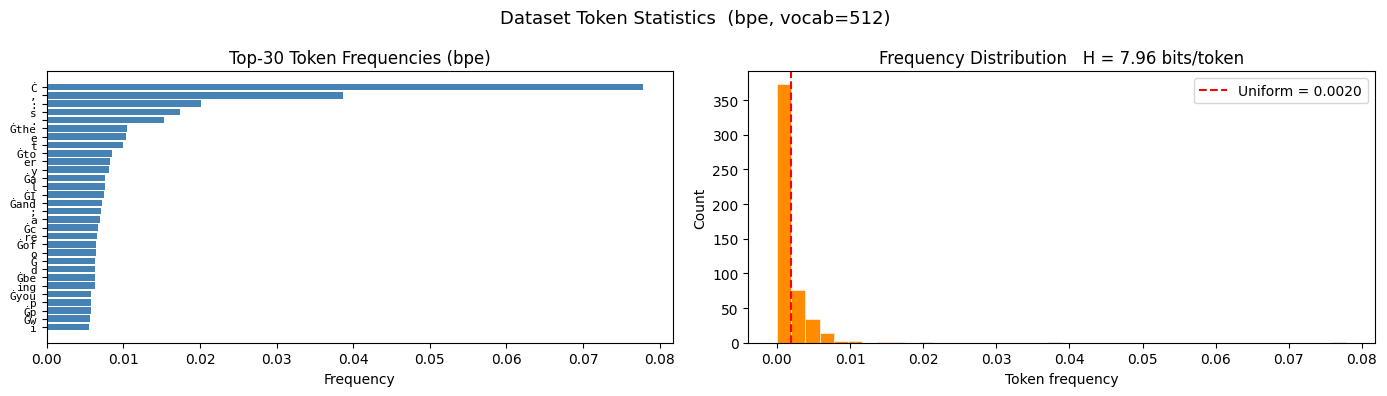


Token-level entropy: 7.96 bits/token
Uniform baseline:    9.00 bits/token


In [6]:
# ── Train / validation split ─────────────────────────────────────────────
TRAIN_FRAC = 0.9
split_idx  = int(TRAIN_FRAC * len(data))
train_data = data[:split_idx]
val_data   = data[split_idx:]

print(f"Train: {len(train_data):>10,} tokens  ({TRAIN_FRAC:.0%})")
print(f"Val:   {len(val_data):>10,} tokens  ({1 - TRAIN_FRAC:.0%})")

# ── Token frequency analysis ─────────────────────────────────────────────
token_counts = torch.bincount(data, minlength=vocab_size)
freqs = token_counts.float() / token_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Top-30 tokens by frequency
top_k = min(30, vocab_size)
top_idx = freqs.argsort(descending=True)[:top_k]
if TOKENIZER_MODE == "char":
    top_labels = [repr(chr(i) if i < 128 else f"#{i}")[1:-1]
                  for i in top_idx.tolist()]
elif TOKENIZER_MODE == "bpe":
    vocab = tokenizer.get_vocab()
    id_to_tok = {v: k for k, v in vocab.items()}
    top_labels = [repr(id_to_tok.get(i.item(), f"#{i.item()}"))[1:-1]
                  for i in top_idx]
else:  # gpt2
    top_labels = [repr(tokenizer.decode([i.item()]))[1:-1] for i in top_idx]
top_freqs = freqs[top_idx].numpy()

axes[0].barh(range(top_k), top_freqs[::-1], color="steelblue")
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(top_labels[::-1], fontfamily="monospace", fontsize=8)
axes[0].set_xlabel("Frequency")
axes[0].set_title(f"Top-{top_k} Token Frequencies ({TOKENIZER_MODE})")

# Entropy
H = -(freqs[freqs > 0] * freqs[freqs > 0].log2()).sum().item()
axes[1].hist(freqs[freqs > 0].numpy(), bins=40, color="darkorange",
             edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Token frequency")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Frequency Distribution   H = {H:.2f} bits/token")
axes[1].axvline(1.0 / vocab_size, color="red", linestyle="--",
                label=f"Uniform = {1.0/vocab_size:.4f}")
axes[1].legend()

plt.suptitle(f"Dataset Token Statistics  ({TOKENIZER_MODE}, vocab={vocab_size})",
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nToken-level entropy: {H:.2f} bits/token")
print(f"Uniform baseline:    {math.log2(vocab_size):.2f} bits/token")


## 2. Model: Stacked ResidualBlock Language Model

Architecture:
```
Token IDs -> Embedding -> [ResidualBlock x N] -> RMSNorm -> LM Head -> logits
```

- **Embedding**: learned lookup table, `vocab_size -> d_input`
- **ResidualBlock**: `RMSNorm -> MambaBlock -> + residual` (from `mamba_block.py`)
- **LM Head**: linear projection `d_input -> vocab_size` (weight-tied with embedding)


In [22]:
# ── Language model config ─────────────────────────────────────────────────
@dataclass
class ShakespeareLMConfig:
    # Tokenizer
    vocab_size:  int  = 65
    # Architecture
    n_layer:     int  = 3
    d_input:     int  = 128
    d_model:     int  = 256
    d_state:     int  = 32
    dt_rank:     int  = 16
    kernel_size: int  = 4
    bias:        bool = False
    conv_bias:   bool = True
    # Training
    seq_len:     int  = 1024    # context window (power of 2 for scan)
    batch_size:  int  = 64
    stride:      int  = 512
    lr:          float = 3e-4
    epochs:      int  = 20
    eval_every_n_batches: int = 250

# ── Language model ────────────────────────────────────────────────────────
class ShakespeareLM(nn.Module):
    def __init__(self, cfg: ShakespeareLMConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = nn.Embedding(cfg.vocab_size, cfg.d_input)
        self.layers    = nn.ModuleList([ResidualBlock(cfg) for _ in range(cfg.n_layer)])
        self.norm_f    = RMSNorm(cfg.d_input)
        self.lm_head   = nn.Linear(cfg.d_input, cfg.vocab_size, bias=False)
        # Weight tying (Embedding and LM head share weights)
        self.lm_head.weight = self.embedding.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx: (B, L) integer token ids
        x = self.embedding(idx)          # (B, L, d_input)
        for layer in self.layers:
            x = layer(x)                 # (B, L, d_input)
        x = self.norm_f(x)              # (B, L, d_input)
        logits = self.lm_head(x)        # (B, L, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=None):
        for _ in range(max_new_tokens):
            # Crop to last seq_len tokens
            idx_cond = idx[:, -self.cfg.seq_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

# ── Instantiate ───────────────────────────────────────────────────────────
cfg = ShakespeareLMConfig(vocab_size=vocab_size)
model = ShakespeareLM(cfg).to(device)

n_params = sum(p.numel() for p in model.parameters())
# Subtract double-counted tied weights
n_params_unique = n_params - model.embedding.weight.numel()
print(f"Total parameters:  {n_params:>10,}")
print(f"Unique parameters: {n_params_unique:>10,}  (embedding weights tied with lm_head)")
print(f"\nModel architecture:")
print(model)


Total parameters:     464,640
Unique parameters:    399,104  (embedding weights tied with lm_head)

Model architecture:
ShakespeareLM(
  (embedding): Embedding(512, 128)
  (layers): ModuleList(
    (0-2): 3 x ResidualBlock(
      (mamba_block): MambaBlock(
        (input_proj): Linear(in_features=128, out_features=256, bias=False)
        (res_proj): Linear(in_features=128, out_features=256, bias=False)
        (output_proj): Linear(in_features=256, out_features=128, bias=False)
        (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
        (x_B_proj): Linear(in_features=256, out_features=32, bias=False)
        (x_C_proj): Linear(in_features=256, out_features=32, bias=False)
        (x_dt_proj): Linear(in_features=256, out_features=16, bias=False)
        (dt_proj): Linear(in_features=16, out_features=256, bias=True)
      )
      (norm): RMSNorm()
    )
  )
  (norm_f): RMSNorm()
  (lm_head): Linear(in_features=128, out_features=512, bias=False)
)


Component                  Params   Share
------------------------------------------
embedding                  65,536   14.1%
layer_0                   132,992   28.6%
layer_1                   132,992   28.6%
layer_2                   132,992   28.6%
norm_f                        128    0.0%
lm_head (tied)                  0    0.0%
------------------------------------------
Unique total              399,104


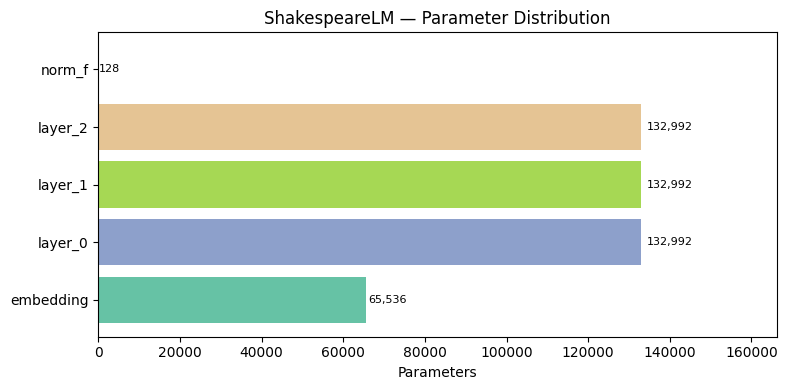

In [8]:
# ── Parameter breakdown ───────────────────────────────────────────────────
groups = {}
groups["embedding"] = model.embedding.weight.numel()
for i, layer in enumerate(model.layers):
    mb = layer.mamba_block
    layer_total = sum(p.numel() for p in layer.parameters())
    groups[f"layer_{i}"] = layer_total
groups["norm_f"] = sum(p.numel() for p in model.norm_f.parameters())
# lm_head is tied to embedding — show it but note it
groups["lm_head (tied)"] = 0

print(f"{'Component':<22} {'Params':>10}  {'Share':>6}")
print("-" * 42)
total_show = sum(groups.values())
for k, n in groups.items():
    pct = 100 * n / total_show if total_show > 0 else 0
    print(f"{k:<22} {n:>10,}  {pct:>5.1f}%")
print("-" * 42)
print(f"{'Unique total':<22} {n_params_unique:>10,}")

fig, ax = plt.subplots(figsize=(8, 4))
plot_groups = {k: v for k, v in groups.items() if v > 0}
names = list(plot_groups.keys())
vals  = list(plot_groups.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(names)))
bars = ax.barh(names, vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va="center", fontsize=8)
ax.set_xlabel("Parameters")
ax.set_title("ShakespeareLM — Parameter Distribution")
ax.set_xlim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()


## 3. Data Pipeline & Profiling

- **Data pipeline**: PyTorch `Dataset` + `DataLoader` with `pin_memory`,
  `num_workers`, and `persistent_workers` for async prefetching
- **Profiler**: `torch.profiler` on one forward + backward step to
  understand where time and memory are spent before committing to full training


In [23]:
# ── Dataset & DataLoader ──────────────────────────────────────────────────
class ShakespeareDataset(Dataset):
    def __init__(self, data, seq_len, stride=None):
        self.data    = data
        self.seq_len = seq_len
        self.stride  = stride or seq_len // 2   # 50% overlap by default

    def __len__(self):
        return max(0, (len(self.data) - self.seq_len) // self.stride)

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start     : start + self.seq_len]
        y = self.data[start + 1 : start + self.seq_len + 1]
        return x, y

train_dataset = ShakespeareDataset(train_data, cfg.seq_len, cfg.stride)
val_dataset   = ShakespeareDataset(val_data,   cfg.seq_len)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True,
)

tokens_per_batch = cfg.batch_size * cfg.seq_len
print(f"Train dataset:  {len(train_dataset):>10,} samples")
print(f"Val dataset:    {len(val_dataset):>10,} samples")
print(f"Train batches / epoch: {len(train_loader):>5}")
print(f"Val   batches / epoch: {len(val_loader):>5}")
print(f"Tokens per batch:      {tokens_per_batch:>5,}  "
      f"({cfg.batch_size} x {cfg.seq_len})")

# Sanity check
xb, yb = next(iter(train_loader))
print(f"\nBatch shapes: x={tuple(xb.shape)}  y={tuple(yb.shape)}")
print(f"Sample input  (first 40 tokens): '{decode(xb[0, :40].tolist())}'")
print(f"Sample target (first 40 tokens): '{decode(yb[0, :40].tolist())}'")


Train dataset:         901 samples
Val dataset:            98 samples
Train batches / epoch:    14
Val   batches / epoch:     1
Tokens per batch:      65,536  (64 x 1024)

Batch shapes: x=(64, 1024)  y=(64, 1024)
Sample input  (first 40 tokens): 'otswold will be found
In Ross and Willoughby, wanting your company,
Which, I protest,'
Sample target (first 40 tokens): 'swold will be found
In Ross and Willoughby, wanting your company,
Which, I protest, hath'


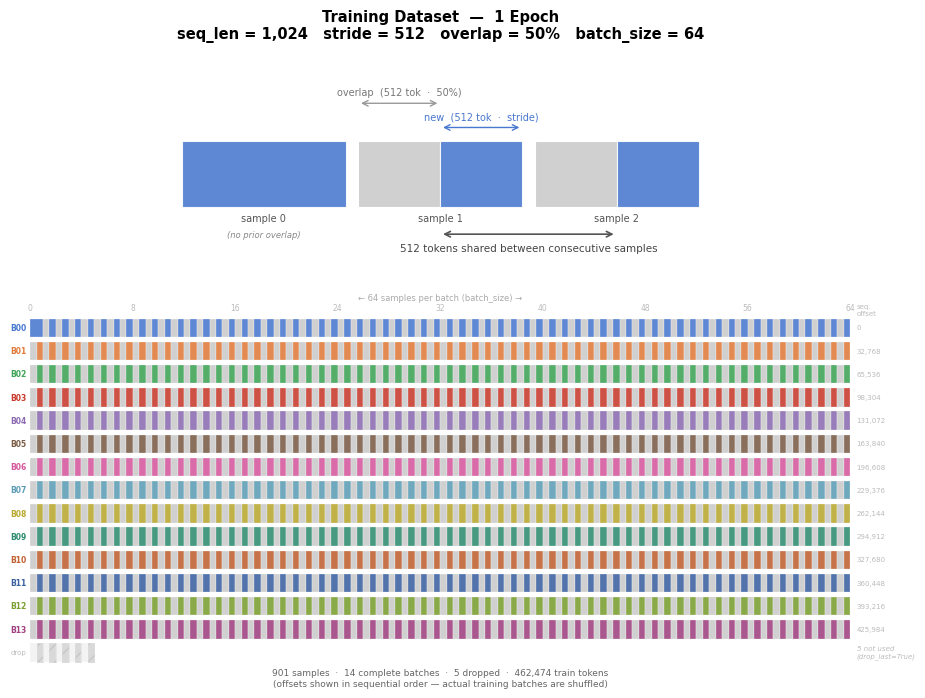

In [29]:
# ── Dataset Calendar Visualization ────────────────────────────────────────
import matplotlib.patches as mpatches

seq_len      = cfg.seq_len
stride       = cfg.stride
batch_size   = cfg.batch_size
n_samples    = len(train_dataset)
n_batches    = len(train_loader)
n_dropped    = n_samples - n_batches * batch_size

overlap      = seq_len - stride
overlap_frac = overlap / seq_len
new_frac     = stride  / seq_len

PALETTE = [
    "#4878CF", "#E07A3A", "#3CA354", "#C8392B", "#8B6BB1",
    "#7A5C45", "#D4569C", "#5C9DB5", "#B8A830", "#2D8B6F",
    "#C06030", "#3A60A0", "#7A9E30", "#A04080", "#409090",
    "#806040",
]
GRAY      = "#d0d0d0"
NEW_ALPHA = 0.88

FIG_W      = 10.0
L_FRAC     = 0.09
R_FRAC     = 0.09
INNER_FRAC = 1.0 - L_FRAC - R_FRAC
CELL_W_IN  = FIG_W * INNER_FRAC / batch_size
CELL_H_IN  = CELL_W_IN * 1.5
GAP_IN     = CELL_H_IN * 0.25
LEG_H_IN   = 2.2
n_rows     = n_batches + (1 if n_dropped else 0)
GRID_H_IN  = n_rows * (CELL_H_IN + GAP_IN) + GAP_IN
FIG_H      = 0.55 + LEG_H_IN + 0.2 + GRID_H_IN + 0.5

fig = plt.figure(figsize=(FIG_W, FIG_H))

# ── Main title ────────────────────────────────────────────────────────────
fig.suptitle(
    f"Training Dataset  —  1 Epoch\n"
    f"seq_len = {seq_len:,}   stride = {stride:,}   "
    f"overlap = {overlap_frac:.0%}   batch_size = {batch_size}",
    fontsize=10.5, fontweight="bold", y=0.999)

# ── Legend axis ───────────────────────────────────────────────────────────
ax_leg = fig.add_axes([L_FRAC, (GRID_H_IN + 0.5 + 0.2) / FIG_H,
                        INNER_FRAC, LEG_H_IN / FIG_H])
ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1); ax_leg.axis("off")

# ── Legend cells ──────────────────────────────────────────────────────────
N_LC = 3; LC_W = 0.20; LC_H = 0.30; LC_G = 0.015
LC_X0 = (1.0 - N_LC * LC_W - (N_LC - 1) * LC_G) / 2
LC_Y0 = 0.35; LC_Y1 = LC_Y0 + LC_H   # 0.35 → 0.65

for i in range(N_LC):
    lx = LC_X0 + i * (LC_W + LC_G)
    if i == 0:
        # Dataset start: no prior window → all tokens are new, no gray zone
        ax_leg.add_patch(mpatches.Rectangle(
            (lx, LC_Y0), LC_W, LC_H,
            fc=PALETTE[0], ec="white", lw=0.8, alpha=NEW_ALPHA))
        ax_leg.text(lx + LC_W / 2, LC_Y0 - 0.03, "sample 0",
                    ha="center", va="top", fontsize=7, color="#555")
        ax_leg.text(lx + LC_W / 2, LC_Y0 - 0.11, "(no prior overlap)",
                    ha="center", va="top", fontsize=6, color="#888", fontstyle="italic")
    else:
        ax_leg.add_patch(mpatches.Rectangle(
            (lx, LC_Y0), LC_W * overlap_frac, LC_H, fc=GRAY, ec="white", lw=0.8))
        ax_leg.add_patch(mpatches.Rectangle(
            (lx + LC_W * overlap_frac, LC_Y0), LC_W * new_frac, LC_H,
            fc=PALETTE[0], ec="white", lw=0.8, alpha=NEW_ALPHA))
        ax_leg.text(lx + LC_W / 2, LC_Y0 - 0.03, f"sample {i}",
                    ha="center", va="top", fontsize=7, color="#555")

# ── Brace annotations above sample 1 — staggered vertically ──────────────
s1_x      = LC_X0 + LC_W + LC_G
s1_ov_end = s1_x + LC_W * overlap_frac
s1_end    = s1_x + LC_W
ov_mid    = s1_x + LC_W * overlap_frac / 2
nw_mid    = s1_x + LC_W * overlap_frac + LC_W * new_frac / 2
ann_y_ov  = LC_Y1 + 0.17   # overlap brace — upper tier
ann_y_nw  = LC_Y1 + 0.06   # new brace — lower tier

ax_leg.annotate("", xy=(s1_ov_end, ann_y_ov), xytext=(s1_x, ann_y_ov),
    arrowprops=dict(arrowstyle="<->", color="#999", lw=1.0))
ax_leg.text(ov_mid, ann_y_ov + 0.025,
            f"overlap  ({overlap:,} tok  ·  {overlap_frac:.0%})",
            ha="center", va="bottom", fontsize=7, color="#777")

ax_leg.annotate("", xy=(s1_end, ann_y_nw), xytext=(s1_ov_end, ann_y_nw),
    arrowprops=dict(arrowstyle="<->", color=PALETTE[0], lw=1.0))
ax_leg.text(nw_mid, ann_y_nw + 0.025,
            f"new  ({stride:,} tok  ·  stride)",
            ha="center", va="bottom", fontsize=7, color=PALETTE[0])

# ── "Same tokens" bracket — sample 1 new zone ↔ sample 2 overlap zone ────
s2_x   = LC_X0 + 2 * (LC_W + LC_G)
bkt_x0 = s1_x + LC_W * overlap_frac
bkt_x1 = s2_x + LC_W * overlap_frac
bkt_y  = LC_Y0 - 0.125
ax_leg.annotate("", xy=(bkt_x1, bkt_y), xytext=(bkt_x0, bkt_y),
    arrowprops=dict(arrowstyle="<->", color="#555", lw=1.2))
ax_leg.text((bkt_x0 + bkt_x1) / 2, bkt_y - 0.04,
    f"{overlap:,} tokens shared between consecutive samples",
    ha="center", va="top", fontsize=7.5, color="#444")

# ── Calendar axis ─────────────────────────────────────────────────────────
ax = fig.add_axes([L_FRAC, 0.5 / FIG_H, INNER_FRAC, GRID_H_IN / FIG_H])

ROW_H = 1.0; GAP_H = 0.25
total_y = n_rows * (ROW_H + GAP_H) + GAP_H
ax.set_xlim(0, batch_size)
ax.set_ylim(total_y + GAP_H * 0.5, -GAP_H * 2.2)   # extra top room for headers
ax.axis("off")

def row_y(b): return GAP_H + b * (ROW_H + GAP_H)

# ── Column headers: sample index within batch ─────────────────────────────
col_step = max(1, batch_size // 8)
for c in range(0, batch_size + 1, col_step):
    ax.text(c, -0.08, str(c), ha="center", va="bottom", fontsize=5.5, color="#bbb")
ax.text(batch_size / 2, -GAP_H * 2.5,
        f"← {batch_size} samples per batch (batch_size) →",
        ha="center", va="bottom", fontsize=6, color="#aaa")

# ── Right-axis header — clearly separate from column labels ───────────────
ax.text(batch_size + 0.5, -GAP_H * 0.8,
        "seq.\noffset",
        ha="left", va="center", fontsize=5, color="#bbb")

# ── Batch rows ────────────────────────────────────────────────────────────
for b in range(n_batches):
    y0    = row_y(b)
    color = PALETTE[b % len(PALETTE)]
    for c in range(batch_size):
        sample_idx = b * batch_size + c
        if sample_idx >= n_samples:
            break
        if sample_idx == 0:
            # First sample in dataset — no predecessor, show fully colored
            ax.add_patch(mpatches.Rectangle(
                (c, y0), 1.0, ROW_H,
                fc=color, ec="white", lw=0.2, alpha=NEW_ALPHA, zorder=2))
        else:
            ax.add_patch(mpatches.Rectangle(
                (c, y0), overlap_frac, ROW_H,
                fc=GRAY, ec="white", lw=0.2, zorder=2))
            ax.add_patch(mpatches.Rectangle(
                (c + overlap_frac, y0), new_frac, ROW_H,
                fc=color, ec="white", lw=0.2, alpha=NEW_ALPHA, zorder=2))
    ax.text(-0.3, y0 + ROW_H / 2, f"B{b:02d}",
            ha="right", va="center", fontsize=5.5, color=color, fontweight="bold")
    ax.text(batch_size + 0.5, y0 + ROW_H / 2,
            f"{b * batch_size * stride:,}",
            ha="left", va="center", fontsize=5, color="#bbb")

# ── Dropped samples row ───────────────────────────────────────────────────
if n_dropped:
    y0 = row_y(n_batches)
    for c in range(n_dropped):
        ax.add_patch(mpatches.Rectangle(
            (c, y0), overlap_frac, ROW_H,
            fc="#ececec", ec="white", lw=0.2, alpha=0.6, zorder=2))
        ax.add_patch(mpatches.Rectangle(
            (c + overlap_frac, y0), new_frac, ROW_H,
            fc="#c0c0c0", ec="#bbb", lw=0.4, alpha=0.6, zorder=2, hatch="//"))
    ax.text(-0.3, y0 + ROW_H / 2, "drop",
            ha="right", va="center", fontsize=5, color="#bbb")
    # Label moved to right side — not inside the cramped hatched cells
    ax.text(batch_size + 0.5, y0 + ROW_H / 2,
            f"{n_dropped} not used\n(drop_last=True)",
            ha="left", va="center", fontsize=5, color="#bbb", fontstyle="italic")

# ── Footer ────────────────────────────────────────────────────────────────
ax.text(batch_size / 2, total_y + GAP_H * 0.45,
    f"{n_samples:,} samples  ·  {n_batches} complete batches  ·  "
    f"{n_dropped} dropped  ·  {len(train_data):,} train tokens\n"
    f"(offsets shown in sequential order — actual training batches are shuffled)",
    ha="center", va="top", fontsize=6.5, color="#666")

plt.show()


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Top-20 operations by CUDA time
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                forward         0.00%       0.000us         0.00%       0.000us       0.000us     513.951ms        55.73%     513.951ms     513.951ms           0 B          

/tmp/ipykernel_2787/1381504547.py:109: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


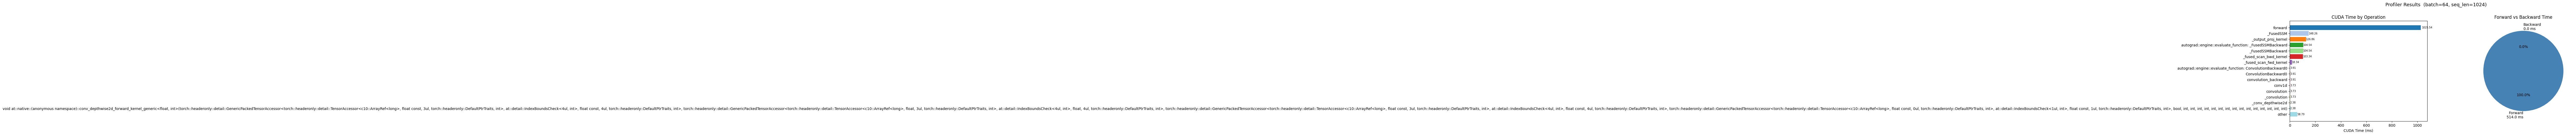


────────────────────────────────────────────────────────────
Peak CUDA memory allocated: 9025.6 MB
Peak CUDA memory reserved:  9188.0 MB
Current CUDA memory allocated: 37.6 MB
────────────────────────────────────────────────────────────

Trace exported to mamba_profile_trace.json
Open https://ui.perfetto.dev and drag the file in to visualize.


ShakespeareLM(
  (embedding): Embedding(65, 128)
  (layers): ModuleList(
    (0-2): 3 x ResidualBlock(
      (mamba_block): MambaBlock(
        (input_proj): Linear(in_features=128, out_features=256, bias=False)
        (res_proj): Linear(in_features=128, out_features=256, bias=False)
        (output_proj): Linear(in_features=256, out_features=128, bias=False)
        (conv1d): Conv1d(256, 256, kernel_size=(4,), stride=(1,), padding=(3,), groups=256)
        (x_B_proj): Linear(in_features=256, out_features=32, bias=False)
        (x_C_proj): Linear(in_features=256, out_features=32, bias=False)
        (x_dt_proj): Linear(in_features=256, out_features=16, bias=False)
        (dt_proj): Linear(in_features=16, out_features=256, bias=True)
      )
      (norm): RMSNorm()
    )
  )
  (norm_f): RMSNorm()
  (lm_head): Linear(in_features=128, out_features=65, bias=False)
)

In [21]:
# ── Torch Profiler: understand where time is spent ───────────────────────
from torch.profiler import profile, ProfilerActivity, record_function

model.eval()

# Warm up the GPU (discard first few runs)
with torch.no_grad():
    for _ in range(3):
        xb, yb = next(iter(val_loader))
        xb, yb = xb.to(device), yb.to(device)
        model(xb, yb)
torch.cuda.synchronize()

# ── Profile a forward + backward pass ─────────────────────────────────────
model.train()
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
) as prof:
    with record_function("forward"):
        logits, loss = model(xb, yb)
    with record_function("backward"):
        loss.backward()

torch.cuda.synchronize()

# ── Top-20 operations by CUDA time ───────────────────────────────────────
print("Top-20 operations by CUDA time")
print("=" * 100)
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=20))

# ── Top-20 by CPU time ──────────────────────────────────────────────────
print("\nTop-20 operations by CPU time")
print("=" * 100)
print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

# ── Memory summary ───────────────────────────────────────────────────────
print("\nTop-15 operations by CUDA memory allocated")
print("=" * 100)
print(prof.key_averages().table(sort_by="cuda_memory_usage", row_limit=15))

# ── Visualize: CUDA time breakdown by op category ────────────────────────
averages = prof.key_averages()

# Group by operation category
op_times = {}
for evt in averages:
    if evt.device_time > 0:
        key = evt.key
        if "aten::" in key:
            cat = key.split("aten::")[-1]
        elif key in ("forward", "backward"):
            cat = key
        else:
            cat = key
        op_times[cat] = op_times.get(cat, 0) + evt.device_time

sorted_ops = sorted(op_times.items(), key=lambda x: x[1], reverse=True)
top_n = 15
top_ops = sorted_ops[:top_n]
other_time = sum(t for _, t in sorted_ops[top_n:])
if other_time > 0:
    top_ops.append(("other", other_time))

op_names = [name for name, _ in top_ops]
op_vals  = [t / 1000 for _, t in top_ops]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.tab20(np.linspace(0, 1, len(op_names)))
bars = axes[0].barh(op_names[::-1], op_vals[::-1], color=colors[::-1])
axes[0].set_xlabel("CUDA Time (ms)")
axes[0].set_title("CUDA Time by Operation")
for bar, v in zip(bars, op_vals[::-1]):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                 f"{v:.2f}", va="center", fontsize=7)

fwd_time = 0
bwd_time = 0
for evt in averages:
    if evt.key == "forward":
        fwd_time = evt.device_time / 1000
    elif evt.key == "backward":
        bwd_time = evt.device_time / 1000
if fwd_time > 0 or bwd_time > 0:
    axes[1].pie(
        [fwd_time, bwd_time],
        labels=[f"Forward\n{fwd_time:.1f} ms", f"Backward\n{bwd_time:.1f} ms"],
        colors=["steelblue", "darkorange"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10},
    )
    axes[1].set_title("Forward vs Backward Time")
else:
    total_cuda = sum(op_vals)
    axes[1].text(0.5, 0.5, f"Total CUDA time: {total_cuda:.1f} ms",
                 ha="center", va="center", fontsize=14,
                 transform=axes[1].transAxes)
    axes[1].set_title("Total CUDA Time")

plt.suptitle(f"Profiler Results  (batch={cfg.batch_size}, seq_len={cfg.seq_len})",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

if torch.cuda.is_available():
    print(f"\n{'─' * 60}")
    print(f"Peak CUDA memory allocated: "
          f"{torch.cuda.max_memory_allocated() / 1024**2:.1f} MB")
    print(f"Peak CUDA memory reserved:  "
          f"{torch.cuda.max_memory_reserved() / 1024**2:.1f} MB")
    print(f"Current CUDA memory allocated: "
          f"{torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"{'─' * 60}")

TRACE_PATH = "mamba_profile_trace.json"
prof.export_chrome_trace(TRACE_PATH)
print(f"\nTrace exported to {TRACE_PATH}")
print("Open https://ui.perfetto.dev and drag the file in to visualize.")

model.zero_grad(set_to_none=True)
model.eval()


## 4. Training

- **Optimizer**: AdamW with cosine LR schedule
- **Loss**: cross-entropy (next token prediction)


In [11]:
torch.cuda.empty_cache()


In [23]:
wandb.init(
    project='mamba-shakespeare-test',
    config=ShakespeareLMConfig,
)

# ── Training loop ─────────────────────────────────────────────────────────
steps_per_epoch = len(train_loader)
total_steps     = cfg.epochs * steps_per_epoch
tokens_per_step = cfg.batch_size * cfg.seq_len

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_steps, eta_min=cfg.lr / 10
)

train_losses = []
val_losses   = []
lr_history   = []
step_times   = []

# wandb.watch(model, log_freq=100)

@torch.no_grad()
def estimate_val_loss(n_batches=20):
    model.eval()
    losses = []
    for i, (xb, yb) in enumerate(val_loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return np.mean(losses)

print(f"Training for {cfg.epochs} epoch(s)  |  {steps_per_epoch:,} steps/epoch  "
      f"|  {total_steps:,} total steps")
print(f"seq_len={cfg.seq_len}  batch={cfg.batch_size}  "
      f"({tokens_per_step:,} tok/step  {total_steps * tokens_per_step:,} tok total)")
print(f"{'─' * 70}")

model.train()
best_val    = float("inf")
global_step = 0

for epoch in range(cfg.epochs):
    epoch_loss = 0.0
    with tqdm(train_loader, unit="batch") as tepoch:
        for batch_idx, (xb, yb) in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            t0 = time.time()

            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            logits, loss = model(xb, yb)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            dt = time.time() - t0
            loss_val = loss.item()
            train_losses.append(loss_val)
            lr = scheduler.get_last_lr()[0]
            lr_history.append(lr)
            step_times.append(dt)
            epoch_loss += loss_val
            global_step += 1
            tepoch.set_postfix(loss=loss_val)
            wandb.log({"Training Loss": loss_val,
                       "Batch Time": dt,
                       "Learning Rate": lr})

            if global_step == 1 or global_step % cfg.eval_every_n_batches == 0:
                val_loss = estimate_val_loss()
                val_losses.append((global_step, val_loss))
                if val_loss < best_val:
                    best_val = val_loss
                ppl = math.exp(val_loss)
                tps = tokens_per_step / np.mean(step_times[-50:])
                print(f"Epoch {epoch+1}/{cfg.epochs}  "
                      f"step {global_step:>6d}/{total_steps}  |  "
                      f"train {loss.item():.4f}  val {val_loss:.4f}  "
                      f"ppl {ppl:.1f}  lr {lr:.1e}  "
                      f"{tps/1000:.1f}k tok/s")
                wandb.log({"Validation Loss": val_loss,
                           "Validation PPL": ppl})

    # End-of-epoch eval
    val_loss = estimate_val_loss()
    ppl = math.exp(val_loss)
    val_losses.append((global_step, val_loss))
    if val_loss < best_val:
        best_val = val_loss
    avg_epoch_loss = epoch_loss / steps_per_epoch
    print(f"{'─' * 70}")
    print(f"Epoch {epoch+1} done  |  avg train {avg_epoch_loss:.4f}  "
          f"val {val_loss:.4f}  ppl {ppl:.1f}")
    print(f"{'─' * 70}")
    wandb.log({"Validation Loss": val_loss,
                           "Validation PPL": ppl})

total_tokens = global_step * tokens_per_step
print(f"\nTraining complete.  {total_tokens:,} tokens processed over "
      f"{cfg.epochs} epoch(s).")
print(f"Best val loss: {best_val:.4f}  (ppl {math.exp(best_val):.1f})")


Training for 20 epoch(s)  |  61 steps/epoch  |  1,220 total steps
seq_len=1024  batch=64  (65,536 tok/step  79,953,920 tok total)
──────────────────────────────────────────────────────────────────────


  0%|          | 0/61 [00:00<?, ?batch/s]

Epoch 1/20  step      1/1220  |  train 4.2847  val 4.2054  ppl 67.0  lr 3.0e-04  58.8k tok/s
──────────────────────────────────────────────────────────────────────
Epoch 1 done  |  avg train 3.0920  val 2.4961  ppl 12.1
──────────────────────────────────────────────────────────────────────


  0%|          | 0/61 [00:00<?, ?batch/s]

──────────────────────────────────────────────────────────────────────
Epoch 2 done  |  avg train 2.2231  val 2.0729  ppl 7.9
──────────────────────────────────────────────────────────────────────


...

──────────────────────────────────────────────────────────────────────
Epoch 18 done  |  avg train 1.3406  val 1.5476  ppl 4.7
──────────────────────────────────────────────────────────────────────


  0%|          | 0/61 [00:00<?, ?batch/s]

──────────────────────────────────────────────────────────────────────
Epoch 19 done  |  avg train 1.3374  val 1.5471  ppl 4.7
──────────────────────────────────────────────────────────────────────


  0%|          | 0/61 [00:00<?, ?batch/s]

──────────────────────────────────────────────────────────────────────
Epoch 20 done  |  avg train 1.3349  val 1.5450  ppl 4.7
──────────────────────────────────────────────────────────────────────

Training complete.  79,953,920 tokens processed over 20 epoch(s).
Best val loss: 1.5450  (ppl 4.7)


## 5. Evaluation & Metrics


In [24]:
# Recreate val_loader without workers (in case persistent workers died)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=0,
    drop_last=True,
)


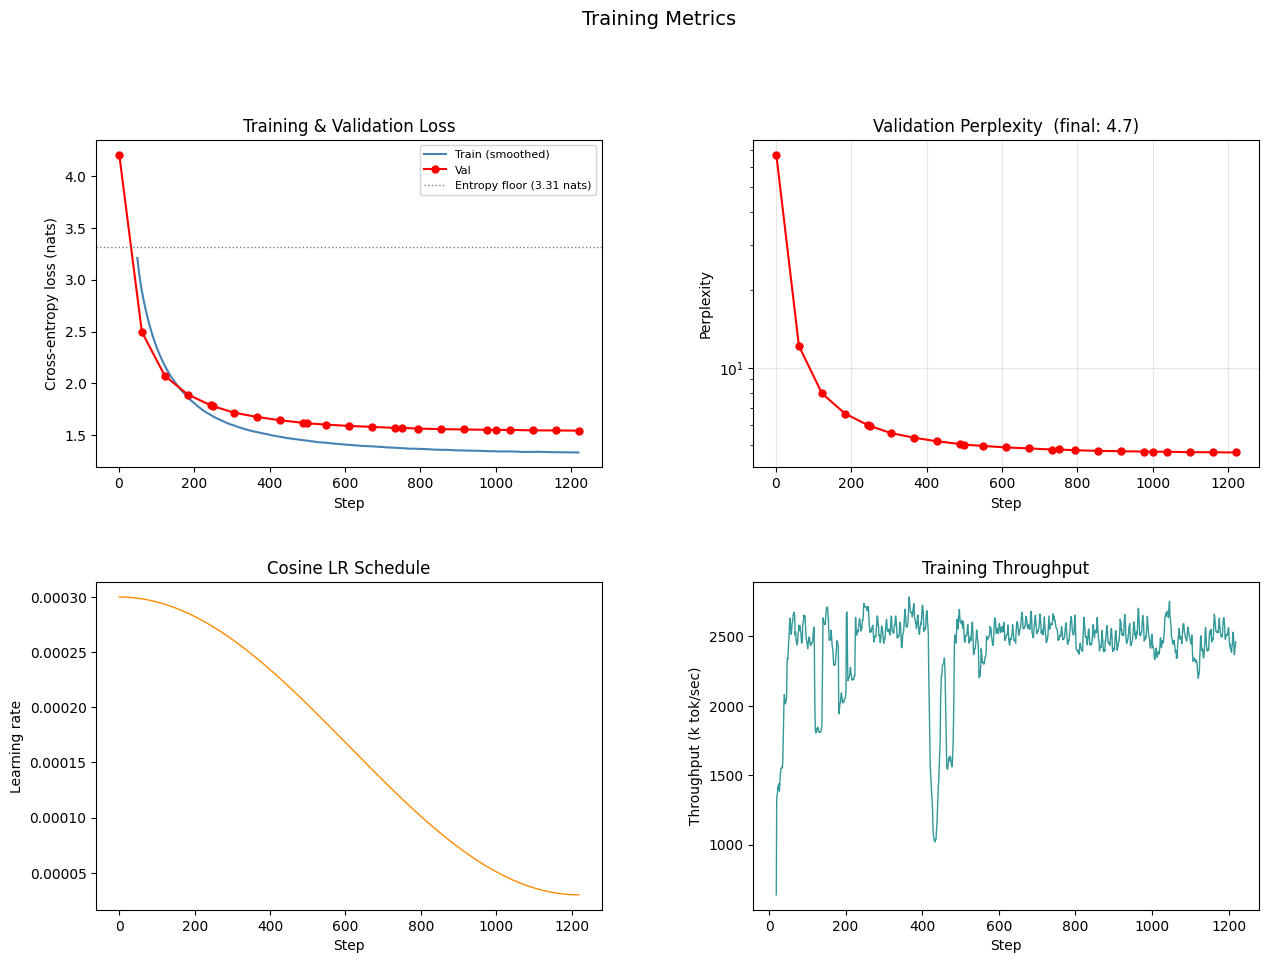

Tokenizer:                     char (vocab=65)
Final val loss (nats):         1.5450
Final val perplexity:          4.7
Best val loss:                 1.5450
Best val perplexity:           4.7
Token entropy (nats):          3.3128
Total training time:           34.9s
Unique parameters:             399,104


In [25]:
# ── Loss & perplexity curves ─────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# (a) Loss curve
ax1 = fig.add_subplot(gs[0, 0])
W = 50
smooth = np.convolve(train_losses, np.ones(W) / W, mode="valid")
ax1.plot(range(W - 1, len(train_losses)), smooth,
         color="steelblue", linewidth=1.5, label="Train (smoothed)")
vx, vy = zip(*val_losses)
ax1.plot(vx, vy, "ro-", markersize=5, linewidth=1.5, label="Val")
ax1.axhline(H * math.log(2), color="gray", linestyle=":", linewidth=1,
            label=f"Entropy floor ({H * math.log(2):.2f} nats)")
ax1.set_xlabel("Step")
ax1.set_ylabel("Cross-entropy loss (nats)")
ax1.set_title("Training & Validation Loss")
ax1.legend(fontsize=8)

# (b) Perplexity
ax2 = fig.add_subplot(gs[0, 1])
val_ppl = [(s, math.exp(l)) for s, l in val_losses]
vx_p, vy_p = zip(*val_ppl)
ax2.plot(vx_p, vy_p, "ro-", markersize=5, linewidth=1.5)
ax2.set_xlabel("Step")
ax2.set_ylabel("Perplexity")
ax2.set_title(f"Validation Perplexity  (final: {vy_p[-1]:.1f})")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

# (c) Learning rate schedule
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(lr_history, color="darkorange", linewidth=1)
ax3.set_xlabel("Step")
ax3.set_ylabel("Learning rate")
ax3.set_title("Cosine LR Schedule")

# (d) Throughput
ax4 = fig.add_subplot(gs[1, 1])
W2 = 20
smooth_times = np.convolve(step_times, np.ones(W2) / W2, mode="valid")
tokens_per_step_metric = cfg.batch_size * cfg.seq_len
throughput = tokens_per_step_metric / smooth_times
ax4.plot(range(W2 - 1, len(step_times)), throughput / 1000,
         color="teal", linewidth=1, alpha=0.8)
ax4.set_xlabel("Step")
ax4.set_ylabel("Throughput (k tok/sec)")
ax4.set_title("Training Throughput")

plt.suptitle("Training Metrics", fontsize=14, y=1.01)
plt.show()

final_val = val_losses[-1][1]
final_ppl = math.exp(final_val)
total_time = sum(step_times)
print(f"{'=' * 50}")
print(f"{'Tokenizer:':<30} {TOKENIZER_MODE} (vocab={vocab_size})")
print(f"{'Final val loss (nats):':<30} {final_val:.4f}")
print(f"{'Final val perplexity:':<30} {final_ppl:.1f}")
print(f"{'Best val loss:':<30} {best_val:.4f}")
print(f"{'Best val perplexity:':<30} {math.exp(best_val):.1f}")
print(f"{'Token entropy (nats):':<30} {H * math.log(2):.4f}")
print(f"{'Total training time:':<30} {total_time:.1f}s")
print(f"{'Unique parameters:':<30} {n_params_unique:,}")
print(f"{'=' * 50}")


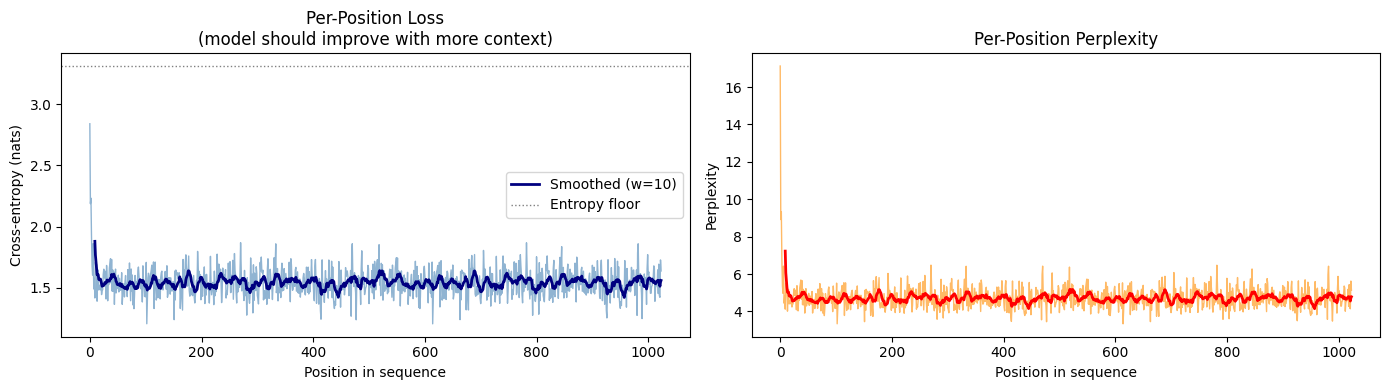

Position  1 loss: 2.841  ppl: 17.1
Position 10 loss: 1.416  ppl: 4.1
Position 1024 loss: 1.637  ppl: 5.1

The model sees more context at later positions -> lower loss


In [26]:
# ── Per-position loss (does the model improve with more context?) ────────
model.eval()

n_eval_batches = 30
pos_losses = torch.zeros(cfg.seq_len, device=device)
pos_counts = torch.zeros(cfg.seq_len, device=device)

with torch.no_grad():
    for i, (xb, yb) in enumerate(val_loader):
        if i >= n_eval_batches:
            break
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits, _ = model(xb, yb)
        log_probs = F.log_softmax(logits, dim=-1)
        target_log_probs = log_probs.gather(2, yb.unsqueeze(-1)).squeeze(-1)
        nll = -target_log_probs
        pos_losses += nll.sum(dim=0)
        pos_counts += xb.shape[0]

avg_pos_loss = (pos_losses / pos_counts).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(avg_pos_loss, color="steelblue", linewidth=1, alpha=0.6)
W3 = 10
smooth_pos = np.convolve(avg_pos_loss, np.ones(W3) / W3, mode="valid")
axes[0].plot(range(W3 - 1, len(avg_pos_loss)), smooth_pos,
             color="navy", linewidth=2, label=f"Smoothed (w={W3})")
axes[0].axhline(H * math.log(2), color="gray", linestyle=":", linewidth=1,
                label="Entropy floor")
axes[0].set_xlabel("Position in sequence")
axes[0].set_ylabel("Cross-entropy (nats)")
axes[0].set_title("Per-Position Loss\n(model should improve with more context)")
axes[0].legend()

pos_ppl = np.exp(avg_pos_loss)
axes[1].plot(pos_ppl, color="darkorange", linewidth=1, alpha=0.6)
smooth_ppl = np.convolve(pos_ppl, np.ones(W3) / W3, mode="valid")
axes[1].plot(range(W3 - 1, len(pos_ppl)), smooth_ppl,
             color="red", linewidth=2)
axes[1].set_xlabel("Position in sequence")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Per-Position Perplexity")

plt.tight_layout()
plt.show()

print(f"Position  1 loss: {avg_pos_loss[0]:.3f}  ppl: {math.exp(avg_pos_loss[0]):.1f}")
print(f"Position 10 loss: {avg_pos_loss[9]:.3f}  ppl: {math.exp(avg_pos_loss[9]):.1f}")
print(f"Position {cfg.seq_len} loss: {avg_pos_loss[-1]:.3f}  "
      f"ppl: {math.exp(avg_pos_loss[-1]):.1f}")
print(f"\nThe model sees more context at later positions -> lower loss")


 Pos      Actual  P(actual)       Top-1  P(top1)       Top-2      Top-3
--------------------------------------------------------------------------------
   0           r     0.0726           e  0.3073           o          a   
   1           o     0.5454           o  0.5454           a          i  *
   2           t     0.0353           k  0.5914           a          u   
   3           h     0.9614           h  0.9614           o          i  *
   4           e     0.8736           e  0.8736           ,          i  *
   5           r     0.9744           r  0.9744           n          c  *
   6                 0.3284              0.3284           ,          '  *
   7           a     0.0825           o  0.0995           a          t   
   8           s     0.1084           n  0.5041           s          g   
   9                 0.8468              0.8468           s          k  *
  10           m     0.0503           t  0.1298           a          I   
  11           y     0.3224      

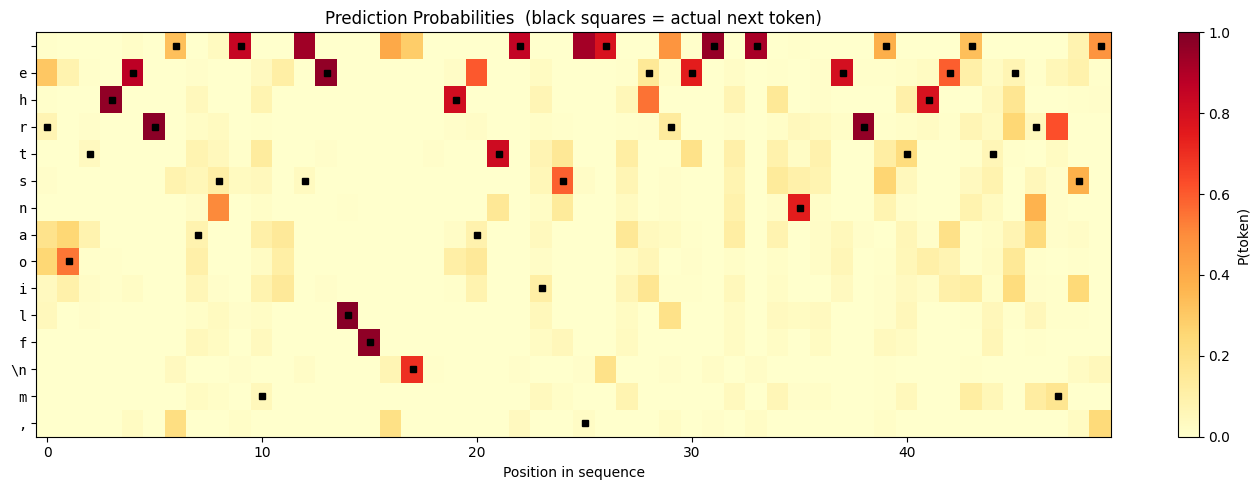

In [27]:
# ── Next-token prediction confidence ──────────────────────────────────────
model.eval()

# Pick a recognisable passage
test_text = "ROMEO: But, soft! what light through yonder window breaks?"
if test_text not in text:
    start = random.randint(0, len(text) - 200)
    test_text = text[start:start + 80]

test_ids = torch.tensor(encode(test_text), dtype=torch.long, device=device).unsqueeze(0)

with torch.no_grad():
    logits, _ = model(test_ids)
    probs = F.softmax(logits[0], dim=-1)

L_show = min(50, test_ids.shape[1] - 1)
print(f"{'Pos':>4}  {'Actual':>10}  {'P(actual)':>9}  "
      f"{'Top-1':>10} {'P(top1)':>8}  {'Top-2':>10} {'Top-3':>10}")
print("-" * 80)

correct = 0
for t in range(L_show):
    actual_id = test_ids[0, t + 1].item()
    p = probs[t]
    p_actual = p[actual_id].item()
    top3 = p.topk(3)
    top_strs = [repr(decode([i.item()]))[1:-1] for i in top3.indices]
    top_probs = top3.values.tolist()
    actual_str = repr(decode([actual_id]))[1:-1]
    hit = "*" if top3.indices[0].item() == actual_id else " "
    if top3.indices[0].item() == actual_id:
        correct += 1
    print(f"{t:>4}  {actual_str:>10}  {p_actual:>9.4f}  "
          f"{top_strs[0]:>10} {top_probs[0]:>7.4f}  "
          f"{top_strs[1]:>10} {top_strs[2]:>10}  {hit}")

print(f"\nTop-1 accuracy: {correct}/{L_show} = {correct/L_show:.1%}")

fig, ax = plt.subplots(figsize=(14, 5))
prob_np = probs[:L_show].cpu().numpy()
flat_sum = prob_np.sum(axis=0)
top_chars_idx = np.argsort(flat_sum)[-15:][::-1]
heatmap = prob_np[:, top_chars_idx].T
char_labels = [repr(decode([i]))[1:-1] for i in top_chars_idx]
im = ax.imshow(heatmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

for t in range(L_show):
    actual = test_ids[0, t + 1].item()
    if actual in top_chars_idx:
        row = list(top_chars_idx).index(actual)
        ax.plot(t, row, "ks", markersize=4)

ax.set_yticks(range(len(char_labels)))
ax.set_yticklabels(char_labels, fontfamily="monospace")
ax.set_xlabel("Position in sequence")
ax.set_title("Prediction Probabilities  (black squares = actual next token)")
plt.colorbar(im, ax=ax, label="P(token)")
plt.tight_layout()
plt.show()


## 6. Text Generation

Let's sample from the trained model with different temperatures and prompts.


In [28]:
# ── Generation function ───────────────────────────────────────────────────
def generate_text(prompt, max_tokens=300, temperature=0.8, top_k=40):
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    out = model.generate(ids, max_new_tokens=max_tokens,
                         temperature=temperature, top_k=top_k)
    return decode(out[0].tolist())

# ── Sample with different temperatures ────────────────────────────────────
prompts = [
    "ROMEO:",
    "To be, or not to be",
    "All that glitters",
    "KING HENRY:",
]

temp_text_table = wandb.Table(columns=["Temp", "text"])

for temp in [0.5, 0.8, 1.0]:
    print(f"\n{'=' * 60}")
    print(f"Temperature = {temp}")
    print(f"{'=' * 60}")
    prompt = random.choice(prompts)
    output = generate_text(prompt, max_tokens=250, temperature=temp, top_k=40)
    print(output)
    temp_text_table.add_data(temp, output)
wandb.log({"Temperature Output": temp_text_table})



Temperature = 0.5
All that glitters to be so offence of the name to defend the morning and her houses, or whom her bear no see the princess and the house the colour and some dear in the time shall have seen to see his son words of the sea, and they are all the morning, the windows sha

Temperature = 0.8
KING HENRY:
Brother is beseech your mother flight as for grace
And hearts, but much makes and to the Earl of what meture-brought thy should be thy people soldiers,
When do it any our good mane,
And as he she's presently in this deeds show it supply that made in

Temperature = 1.0
All that glitters, yet help twice to death!
A prescired, to her dead.

VIRGILIA:
Rest did
soe.

HENRY YBfonged,
not twenty slain
She crown see whither rocks thepherd:
Who known dugs drumiis, poor Eb:
You queen?

MTTREMES:
That Edward,soek the time,
The truth? a Tribu


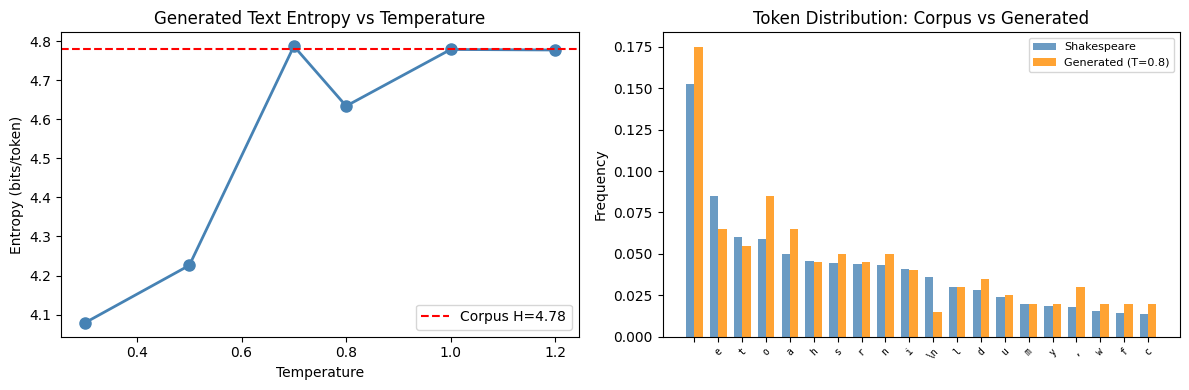

In [29]:
# ── Temperature comparison: entropy of generated text ─────────────────────
temperatures = [0.3, 0.5, 0.7, 0.8, 1.0, 1.2]
gen_entropies = []
gen_samples   = []

for temp in temperatures:
    model.eval()
    ids = torch.tensor(encode("HAMLET:\n"), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        out = model.generate(ids, max_new_tokens=500, temperature=temp, top_k=50)
    gen_text = decode(out[0].tolist())
    gen_samples.append(gen_text[:200])

    gen_ids = torch.tensor(encode(gen_text), dtype=torch.long)
    gen_counts = torch.bincount(gen_ids, minlength=vocab_size).float()
    gen_freq   = gen_counts / gen_counts.sum()
    gen_H = -(gen_freq[gen_freq > 0] * gen_freq[gen_freq > 0].log2()).sum().item()
    gen_entropies.append(gen_H)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(temperatures, gen_entropies, "o-", color="steelblue",
             linewidth=2, markersize=8)
axes[0].axhline(H, color="red", linestyle="--", label=f"Corpus H={H:.2f}")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel("Entropy (bits/token)")
axes[0].set_title("Generated Text Entropy vs Temperature")
axes[0].legend()

idx_08 = temperatures.index(0.8)
gen_08 = gen_samples[idx_08]
gen_counts_08 = torch.bincount(
    torch.tensor(encode(gen_08), dtype=torch.long), minlength=vocab_size
).float()
gen_freq_08 = gen_counts_08 / gen_counts_08.sum()

top_20 = freqs.argsort(descending=True)[:20]
x_pos = np.arange(20)
w = 0.35
axes[1].bar(x_pos - w/2, freqs[top_20].numpy(), w,
            label="Shakespeare", color="steelblue", alpha=0.8)
axes[1].bar(x_pos + w/2, gen_freq_08[top_20].numpy(), w,
            label="Generated (T=0.8)", color="darkorange", alpha=0.8)
axes[1].set_xticks(x_pos)
if TOKENIZER_MODE == "char":
    xlabels = [repr(decode([i.item()]))[1:-1] for i in top_20]
else:
    xlabels = [repr(decode([i.item()]))[1:-1][:8] for i in top_20]
axes[1].set_xticklabels(xlabels, fontfamily="monospace", fontsize=7, rotation=45)
axes[1].set_ylabel("Frequency")
axes[1].set_title("Token Distribution: Corpus vs Generated")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [30]:
# ── Final showcase generation ─────────────────────────────────────────────
print("=" * 60)
print("FINAL GENERATION SHOWCASE")
print("=" * 60)

showcase_prompts = [
    "JULIET:\nO Romeo, Romeo! wherefore art thou Romeo?\n",
    "HAMLET:\nTo be, or not to be, that is the question:\n",
    "First Citizen:\nBefore we proceed any further, hear me speak.\n",
]

final_text_table = wandb.Table(columns=["Prompt", "text"])

for prompt in showcase_prompts:
    print(f"\n{'─' * 60}")
    print(f"PROMPT: {prompt.strip()[:60]}...")
    print(f"{'─' * 60}")
    output = generate_text(prompt, max_tokens=300, temperature=0.8, top_k=40)
    print(output)
    final_text_table.add_data(prompt.strip(), output)

wandb.log({"Final Generation": final_text_table})
print(f"\n{'═' * 60}")
print(f"Model: {cfg.n_layer}-layer Mamba LM, {n_params_unique:,} params")
print(f"Tokenizer: {TOKENIZER_MODE} (vocab={vocab_size})")
print(f"Trained on {len(train_data):,} tokens for {cfg.epochs} epoch(s)")
print(f"Final perplexity: {math.exp(best_val):.1f}")
print(f"{'═' * 60}")


FINAL GENERATION SHOWCASE

────────────────────────────────────────────────────────────
PROMPT: JULIET:
O Romeo, Romeo! wherefore art thou Romeo?...
────────────────────────────────────────────────────────────
JULIET:
O Romeo, Romeo! wherefore art thou Romeo?

PAULINA:
Iars far no less and myself;
The offices come, sir, though quickly as the issue men of I thoughtir treason
But to do I fear these of his this action, the other dead, that you all of my mere at as much that twenty my birds for that he looks, and gives her; and so pervices? To prevail'd hran

────────────────────────────────────────────────────────────
PROMPT: HAMLET:
To be, or not to be, that is the question:...
────────────────────────────────────────────────────────────
HAMLET:
To be, or not to be, that is the question:
Thou shalt.

POMPEY:
If were provisy and thou are in arms.

GLOUCESTER:
Now?

ISABELLA:
O this man shall before her life.

MARIAK:
For I be at would be be and were easing showpless of cansent follow'd to